## 06 - Explaining the model with SHAP

In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

df = pd.read_csv("../data/processed/telco_clean.csv")
X = df.drop(columns="Churn")
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)
preprocessor.set_output(transform="pandas")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", random_state=42,
    )),
])
xgb.fit(X_train, y_train)
X_train.shape, X_test.shape

((5634, 19), (1409, 19))

### SHAP values
SHAP shows how much each feature pushed a customer's churn risk up or down.

In [2]:
X_test_t = xgb.named_steps["preprocess"].transform(X_test)
model = xgb.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_t)
shap_values.values.shape

(1409, 40)

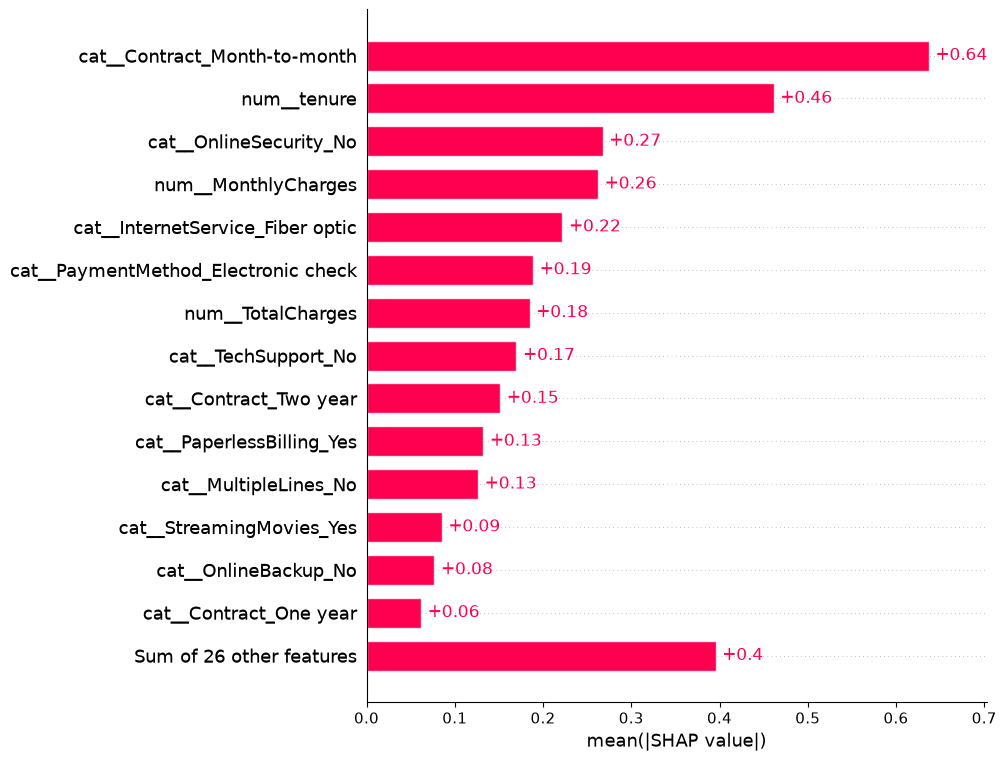

In [3]:
shap.plots.bar(shap_values, max_display=15)

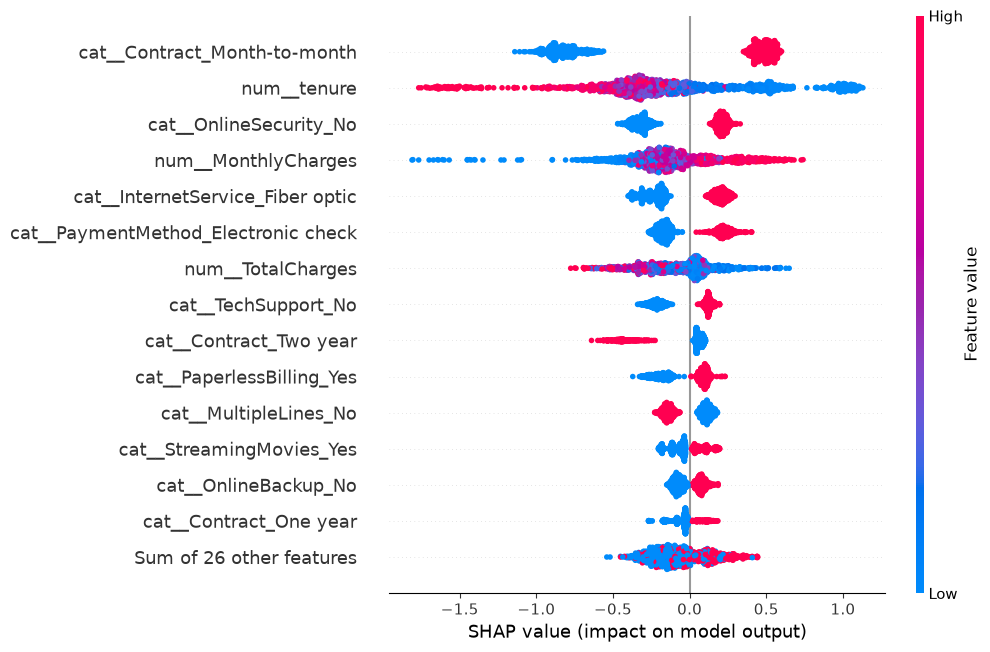

In [4]:
shap.plots.beeswarm(shap_values, max_display=15)

SHAP confirms the EDA: month-to-month contracts, short tenure, fibre optic internet and electronic check payment push churn risk up; two-year contracts push it down. It also surfaces customers without online security or tech support as higher risk, which the EDA had not examined. SHAP shows what the model relies on, not causal effects, and correlated features (contract columns; tenure, monthly and total charges) share credit.

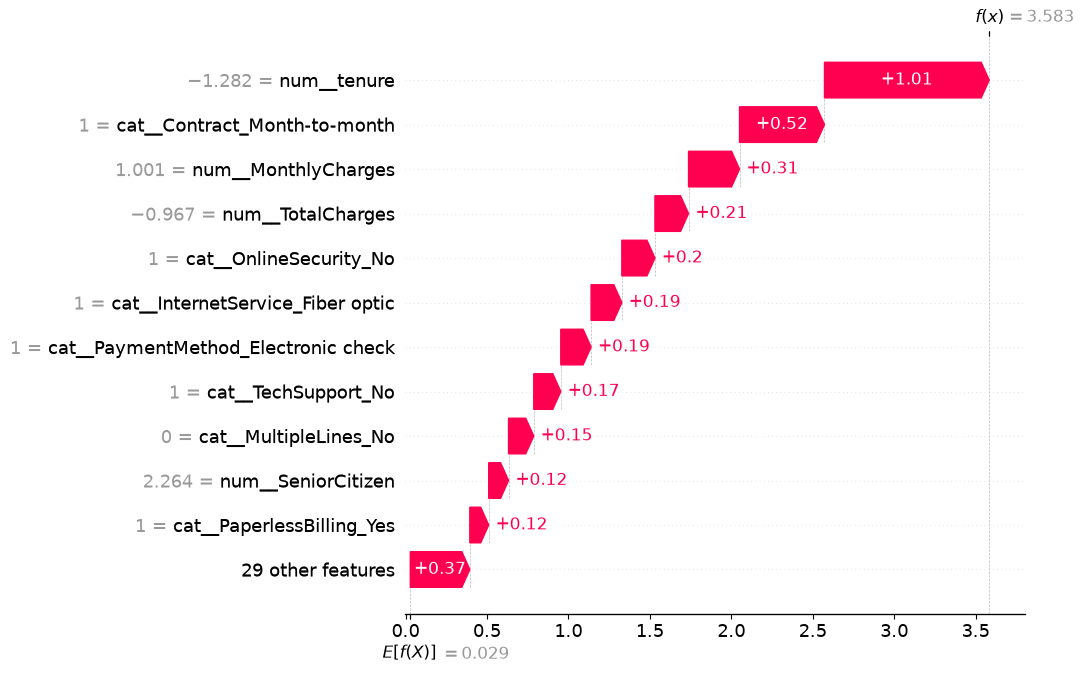

In [5]:
proba_test = model.predict_proba(X_test_t)[:, 1]
i = int(np.argmax(proba_test))
shap.plots.waterfall(shap_values[i], max_display=12)

Waterfall for the highest-risk test customer: very short tenure, month-to-month contract, above-average monthly charges, fibre optic, electronic check, and no online security or tech support all push risk up; nothing pushes it down. SHAP values are in log-odds, and because of class weighting the model's raw probabilities are not calibrated to the true churn rate, so scores are best used for ranking.

In [6]:
import os
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)

shap.plots.bar(shap_values, max_display=15, show=False)
plt.savefig("../reports/figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.close()

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.savefig("../reports/figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.close()